# Studies 3 & 4 Analysis
### Python replication of `Study_3_and_4_code.do` (Stata)

**Paper**: Pennycook et al. (2021, *Nature*) — "Shifting attention to accuracy can reduce misinformation online"

**Research question**: Can a brief "accuracy nudge" — asking people to judge the accuracy of a single unrelated headline — reduce willingness to share misinformation on social media?


| Condition | Pre-task |
|-----------|----------|
| 0 — Control | None |
| 1 — Treatment | Rate how *accurate* a neutral headline is |

**Primary outcome**: `sm` — sharing willingness on a continuous 0–1 scale (rescaled from a 6-point Likert item).  
The key finding is the **interaction** between condition and headline veracity: does the nudge widen the true/false sharing gap?

---

**Additions (beyond original Stata code)**  
- Chi-square balance check (paper: Studies 3 & 4 separately) (Paper O, Stata X)
- Bayesian t-tests (BF₁₀) for AccImp/AccImp_Friends null effects  (Paper O, Stata X)
- Table S3 — detailed simple effects (partisanship × concordance) (Paper O, Stata X)
- CRT analysis (PAP O, Paper X, Stata X)

## 1. Setup — Imports & Helper Functions

### Imports & global settings

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pingouin as pg
import warnings
import re
from scipy.stats import zscore
warnings.filterwarnings('ignore')

# Color palette
COND_COLORS = {
    0: '#F4CCCC',   # Control   — light pink
    1: '#CFE2F3',   # Treatment — light blue
}
COND_LABELS = {
    0: 'Control',
    1: 'Treatment',
}

DATA_DIR   = "./"          # input data location
OUTPUT_DIR = "./output/"   # all outputs
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

### Helper functions

**`ttest_report`** — Welch's independent-samples t-test.

**`bayesian_ttest_report`** — Bayesian t-test via `pingouin` (Cauchy prior r = √2/2 ≈ 0.707, matching the paper's BF₁₀ values).

**`two_way_cluster_ols`** — OLS regression with two-way clustered standard errors (Cameron, Gelbach & Miller 2011).
Clustering simultaneously by participant (`id`) and headline (`item_num`).

$$\hat{V}_{\text{2-way}} = \hat{V}_{\text{cluster by id}} + \hat{V}_{\text{cluster by item}} - \hat{V}_{\text{HC1}}$$

This is the Python equivalent of Stata's `cluster2` command used in the original `.do` file.

In [2]:
def ttest_report(label, group0, group1):
    """Independent-samples Welch t-test; prints means, t, p."""
    g0, g1 = group0.dropna(), group1.dropna()
    if len(g0) < 2 or len(g1) < 2:
        print(f"  {label}: insufficient data"); return
    t, p = stats.ttest_ind(g0, g1)
    print(f"  {label}: n0={len(g0)}, mean0={g0.mean():.4f} | "
          f"n1={len(g1)}, mean1={g1.mean():.4f} | t={t:.4f}, p={p:.4f}")


def bayesian_ttest_report(label, group0, group1):
    """Bayesian independent t-test via pingouin (Cauchy r=√2/2); prints BF₁₀."""
    g0, g1 = group0.dropna(), group1.dropna()
    if len(g0) < 2 or len(g1) < 2:
        print(f"  {label}: insufficient data"); return
    res = pg.bayesfactor_ttest(stats.ttest_ind(g0, g1).statistic,
                               len(g0), len(g1), paired=False)
    print(f"  {label}: BF₁₀ = {res:.4f}")


def two_way_cluster_ols(formula, data, cluster1, cluster2_col, label=""):
    """OLS with two-way clustered SEs (Cameron, Gelbach & Miller 2011)."""
    data = data.reset_index(drop=True)
    r1  = smf.ols(formula, data=data).fit(cov_type='cluster', cov_kwds={'groups': data[cluster1]})
    r2  = smf.ols(formula, data=data).fit(cov_type='cluster', cov_kwds={'groups': data[cluster2_col]})
    r0  = smf.ols(formula, data=data).fit(cov_type='HC1')
    model = smf.ols(formula, data=data).fit()

    vcov_2way = r1.cov_params() + r2.cov_params() - r0.cov_params()
    se     = np.sqrt(np.diag(vcov_2way))
    t_vals = model.params / se
    p_vals = 2 * stats.t.sf(np.abs(t_vals), df=model.df_resid)
    ci_lo  = model.params - 1.96 * se
    ci_hi  = model.params + 1.96 * se

    summary = pd.DataFrame({'coef': model.params, 'se': se, 
                            'CI_lo': ci_lo, 'CI_hi': ci_hi,
                            't': t_vals, 'p': p_vals})
    if label:
        print(f"\n{'='*60}\nREGRESSION: {label}\n{'='*60}")
    print(summary.to_string(float_format=lambda x: f"{x:.4f}"))
    print(f"  N={int(model.nobs)}, R²={model.rsquared:.4f}")
    return model, summary

## 2. Data Loading & Sample Description

**Steps**:
1. Load raw CSV and apply exclusions (did not finish survey; failed Facebook check)
2. Print descriptive statistics
3. Chi-square test — verify that sharer proportions are balanced across conditions (ruling out selection bias from random assignment)

**Exclusion criteria**:
- `didnt_finish == 1` — incomplete survey  
- `fb == 2` — failed bot/attention check

**Chi-square H₀**: Proportion of sharers (`socialmedia_chk == 1`) is equal across conditions. If p > 0.05, random assignment was successful and groups are comparable.
- Paper reports Study 3: χ²(1, n=1158)=0.156, p=0.69; Study 4: χ²(1, n=1248)=0.988, p=0.32

In [41]:
# Load and append
df3 = pd.read_csv(DATA_DIR + "Study_3_data.csv", low_memory=False)
df3.columns = df3.columns.str.lower()
df3['study'] = 3

df4 = pd.read_csv(DATA_DIR + "Study_4_data.csv", low_memory=False)
df4.columns = df4.columns.str.lower()
df4['study'] = 4

df = pd.concat([df3, df4], ignore_index=True, sort=False)

# Save crt3_3 for section 10
crt3_3_text = df['crt3_3'].copy()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['id'] = np.arange(1, len(df) + 1)

# Exclusion flags
df['didnt_finish'] = df['socialmedia_chk'].isna().astype(int)
df = df[(df['didnt_finish'] != 1) & (df['fb'] != 2)].copy()

# Restore crt3_3 text responses for section 10
df['crt3_3_text'] = crt3_3_text.loc[df.index].values

print("=== table didnt_finish × fb × study ===")
print(pd.crosstab([df['didnt_finish'], df['fb']], df['study']))

# Apply exclusions
df = df[(df['didnt_finish'] != 1) & (df['fb'] != 2)].copy()
print(f"\nAfter exclusions: N = {len(df)}")

for s in [3, 4]:
    sub = df[df['study'] == s]
    print(f"\n=== Study {s}: sum id age ===")
    for v in ['id', 'age']:
        sv = sub[v].dropna()
        print(f"  {v}: Obs={len(sv)}, Mean={sv.mean():.5f}, SD={sv.std():.5f}, "
              f"Min={sv.min()}, Max={sv.max()}")

print("\n=== table study x sex ===")
print(pd.crosstab(df['study'], df['sex']))

print("\n=== table socialmedia_chk x study ===")
print(pd.crosstab(df['study'], df['socialmedia_chk']))

for s in [3, 4]:
    sub = df[(df['study'] == s) & (df['socialmedia_chk'] == 1)]
    print(f"\n=== Study {s}: participants sum id age ===")
    for v in ['id', 'age']:
        sv = sub[v].dropna()
        print(f"  {v}: Obs={len(sv)}, Mean={sv.mean():.5f}")
    print(f"  sex: {sub['sex'].value_counts().sort_index().to_dict()}")

# Chi-square: sharer balance across conditions
df['socialmedia_chk1'] = np.where(
    df['socialmedia_chk'].isna(), np.nan,
    (df['socialmedia_chk'] == 1).astype(float))

# Recode condition: 1→0 (Control), 2→1 (Treatment)
df['condition'] = df['condition'] - 1

print("\n=== Chi-square: sharer balance by condition ===")
for s in [3, 4]:
    sub = df[df['study'] == s].copy()
    sub = sub[sub['socialmedia_chk'].isin([1, 2])].copy()
    sub['is_sharer'] = (sub['socialmedia_chk'] == 1).astype(int)
    ct = pd.crosstab(sub['is_sharer'], sub['condition'])
    chi2_val, p_chi, dof, _ = stats.chi2_contingency(ct)
    n = len(sub)
    print(f"  Study {s}: χ²({dof}, n={n}) = {chi2_val:.3f}, p = {p_chi:.4f}")
    print(ct.to_string())

=== table didnt_finish × fb × study ===
study                3     4
didnt_finish fb             
0            1.0  1158  1248

After exclusions: N = 2406

=== Study 3: sum id age ===
  id: Obs=1158, Mean=588.45682, SD=340.46648, Min=1, Max=1237
  age: Obs=1158, Mean=33.74093, SD=10.48826, Min=2.0, Max=79.0

=== Study 4: sum id age ===
  id: Obs=1248, Mean=1879.80288, SD=361.73990, Min=1255, Max=2546
  age: Obs=1246, Mean=33.25281, SD=10.00929, Min=17.0, Max=81.0

=== table study x sex ===
sex    1.0  2.0
study          
3      453  703
4      490  757

=== table socialmedia_chk x study ===
socialmedia_chk  1.0  2.0  3.0
study                         
3                727  431    0
4                780  466    2

=== Study 3: participants sum id age ===
  id: Obs=727, Mean=597.77442
  age: Obs=727, Mean=34.55571
  sex: {1.0: 274, 2.0: 451}

=== Study 4: participants sum id age ===
  id: Obs=780, Mean=1872.68974
  age: Obs=778, Mean=33.59254
  sex: {1.0: 282, 2.0: 497}

=== Chi-square: 

## 3. Reshape: Wide → Long Format

The raw data is **wide format** (one row per participant, one column per headline). Regression requires **long format** (one row per participant × headline observation).

**Key variables created**:

| Variable | Description |
|----------|-------------|
| `real` | 0 = false headline, 1 = true headline |
| `sm` | Sharing willingness rescaled to [0, 1] via `(raw − 1) / 5` |
| `item_num` | 1–12 = false headlines; true headlines get **+12** (→ 13–24); Study 3 gets further **+24** offset (→ 25–48) for two-way clustering |
| `Bsm` | Binary share intent: `round(sm)` (0 or 1) — used for Figure 2a,b bar plots |
| `politically_concordant` | 1 if partisan alignment: (item 1–6 & Republican) or (item 7–12 & Democrat) |

> **Note on `item_num` encoding**: the +12 shift separates false (1-12) and true (13-24) items within each study  
> so that two-way clustering by `item_num` treats them as distinct clusters.  
> The Study 3 offset (+24) further separates Study 3 items from Study 4 items in the pooled analysis.

In [10]:
# Build long-format rows
rows = []
for _, row in df.iterrows():
    study = int(row['study'])
    for item_n in range(1, 13):
        fake_col = f'fake{item_n}_3'
        real_col = f'real{item_n}_3'
        sm_fake  = row.get(fake_col, np.nan)
        sm_real  = row.get(real_col, np.nan)

        base = {
            'id': row['id'],
            'study': study,
            'condition': row.get('condition', np.nan),
            'demrep': row.get('demrep', np.nan),
            'age': row.get('age', np.nan),
            'sex': row.get('sex', np.nan),
            'fb': row.get('fb', np.nan),
            'socialmedia_chk': row.get('socialmedia_chk', np.nan),
            'socialmedia_chk1':row.get('socialmedia_chk1', np.nan),
            'accimp': row.get('accimp', np.nan),
            'accimp_friends':  row.get('accimp_friends', np.nan),
            # CRT variables (PAP preregistered)
            'crt1_1': row.get('crt1_1', np.nan),
            'crt1_2': row.get('crt1_2', np.nan),
            'crt1_3': row.get('crt1_3', np.nan),
            'item_n_raw': item_n,
        }

        r_fake = {**base,
                  'sm': sm_fake,
                  'real': 0,
                  'item_num': item_n + (24 if study == 3 else 0)}
        r_real = {**base,
                  'sm': sm_real,
                  'real': 1,
                  'item_num': item_n + 12 + (24 if study == 3 else 0)}
        rows.extend([r_fake, r_real])

long = pd.DataFrame(rows)

# Rescale sm to [0, 1]
long['sm'] = (long['sm'] - 1) / 5

# Political concordance (item 1-6 = pro-Republican fake/real)
# item_n_raw 1-6: originally pro-Republican; 7-12: originally pro-Democrat
long['politically_concordant'] = (
    ((long['item_n_raw'] <= 6) & (long['demrep'] == 2)) |
    ((long['item_n_raw'] > 6)  & (long['demrep'] == 1))
).astype(float)

# Binary sharing variable
long['Bsm'] = long['sm'].round()

# Participants subset
sharers_long = long[long['socialmedia_chk'] == 1].copy()

print(f"Long-format rows: {len(long)}  "
      f"({len(df)} participants x 12 items x 2 veracity types)")
print(f"Sharers subset rows: {len(sharers_long)}")
long[['id','item_num','real','condition','sm','Bsm']].head(6)

Long-format rows: 57744  (2406 participants x 12 items x 2 veracity types)
Sharers subset rows: 36168


,id,item_num,real,condition,sm,Bsm
0,1,25,0,1.0,0.0,0.0
1,1,37,1,1.0,0.6,1.0
2,1,26,0,1.0,0.0,0.0
3,1,38,1,1.0,0.6,1.0
4,1,27,0,1.0,0.8,1.0
5,1,39,1,1.0,0.4,0.0


## 4. Descriptive Figures

### Figure 2a (Study 3) and Figure 2b (Study 4) — Mean Sharing Rate by Condition and Veracity

Bar chart of mean binary sharing rate (`Bsm`) for false and true headlines across the two conditions.  
Error bars are 95% CIs from two-way clustered standard errors.

### Extended Data Figure 2 — Full Distribution of Sharing Intentions

Distribution of 6-point Likert responses for each treatment × veracity combination.

| sm value | Response label |
|----------|---------------|
| 0.0 | Extremely unlikely |
| 0.2 | Moderately unlikely |
| 0.4 | Slightly unlikely |
| 0.6 | Slightly likely |
| 0.8 | Moderately likely |
| 1.0 | Extremely likely |

In [11]:
def mean_ci95_clustered(subset, outcome='Bsm', cluster1='id', cluster2_col='item_num'):
    """Mean ± 95% CI half-width using two-way clustered SEs."""
    sub = subset[[outcome, cluster1, cluster2_col]].dropna()
    if len(sub) < 3:
        return sub[outcome].mean(), 0
    r1 = smf.ols(f'{outcome} ~ 1', data=sub).fit(
         cov_type='cluster', cov_kwds={'groups': sub[cluster1]})
    r2 = smf.ols(f'{outcome} ~ 1', data=sub).fit(
         cov_type='cluster', cov_kwds={'groups': sub[cluster2_col]})
    r0 = smf.ols(f'{outcome} ~ 1', data=sub).fit(cov_type='HC1')
    v_2way = (r1.cov_params().values[0,0] + r2.cov_params().values[0,0]
              - r0.cov_params().values[0,0])
    se = np.sqrt(max(v_2way, 0))
    mean_val = smf.ols(f'{outcome} ~ 1', data=sub).fit().params['Intercept']
    return mean_val, 1.96 * se


=== Study 3 Figure 2 cell means (Bsm %) ===
           False (%)  True (%)  Discernment (pp)
Control         28.3      33.4               5.0
Treatment       22.2      34.3              12.1

=== Study 4 Figure 2 cell means (Bsm %) ===
           False (%)  True (%)  Discernment (pp)
Control         32.1      36.0               3.9
Treatment       25.6      37.9              12.3


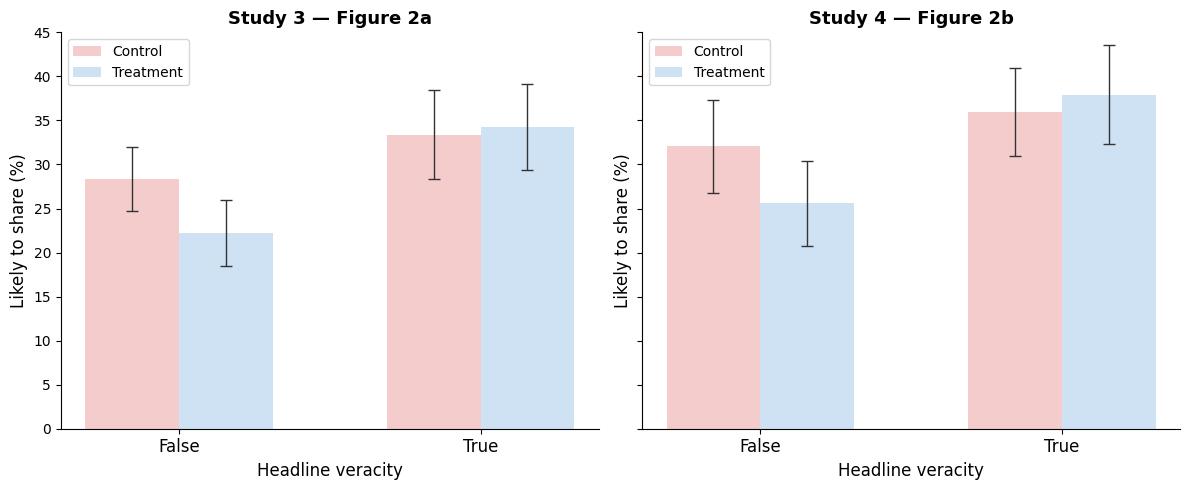


Saved: Figure_2ab_Studies34.png


In [12]:
# Figure 2a (Study 3) and Figure 2b (Study 4)
bar_w, group_gap = 0.28, 0.9
x_centers = np.array([0, group_gap])
conditions = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
study_labels = {3: 'Study 3 — Figure 2a', 4: 'Study 4 — Figure 2b'}

for ax, study_id in zip(axes, [3, 4]):
    sub_study = sharers_long[sharers_long['study'] == study_id]
    for i, cond in enumerate(conditions):
        offsets = x_centers + (i - 0.5) * bar_w
        means, errs = [], []
        for v in [0, 1]:
            subset = sub_study[(sub_study['condition'] == cond) & (sub_study['real'] == v)]
            m, e = mean_ci95_clustered(subset)
            means.append(m * 100); errs.append(e * 100)
        ax.bar(offsets, means, width=bar_w,
               color=COND_COLORS[cond], label=COND_LABELS[cond],
               yerr=errs, capsize=4,
               error_kw=dict(elinewidth=1, ecolor='#333333'))

    ax.set_xticks(x_centers)
    ax.set_xticklabels(['False', 'True'], fontsize=12)
    ax.set_xlabel('Headline veracity', fontsize=12)
    ax.set_ylabel('Likely to share (%)', fontsize=12)
    ax.set_title(study_labels[study_id], fontsize=13, fontweight='bold')
    ax.set_ylim(0, 45)
    ax.legend(fontsize=10, frameon=True, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Print cell means
    print(f"\n=== Study {study_id} Figure 2 cell means (Bsm %) ===")
    tbl = (sub_study.groupby(['condition', 'real'])['Bsm']
           .mean().unstack() * 100)
    tbl.columns = ['False (%)', 'True (%)']
    tbl.index = [COND_LABELS[c] for c in tbl.index]
    tbl['Discernment (pp)'] = tbl['True (%)'] - tbl['False (%)']
    print(tbl.to_string(float_format=lambda x: f"{x:.1f}"))

plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'Figure_2ab_Studies34.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: Figure_2ab_Studies34.png")

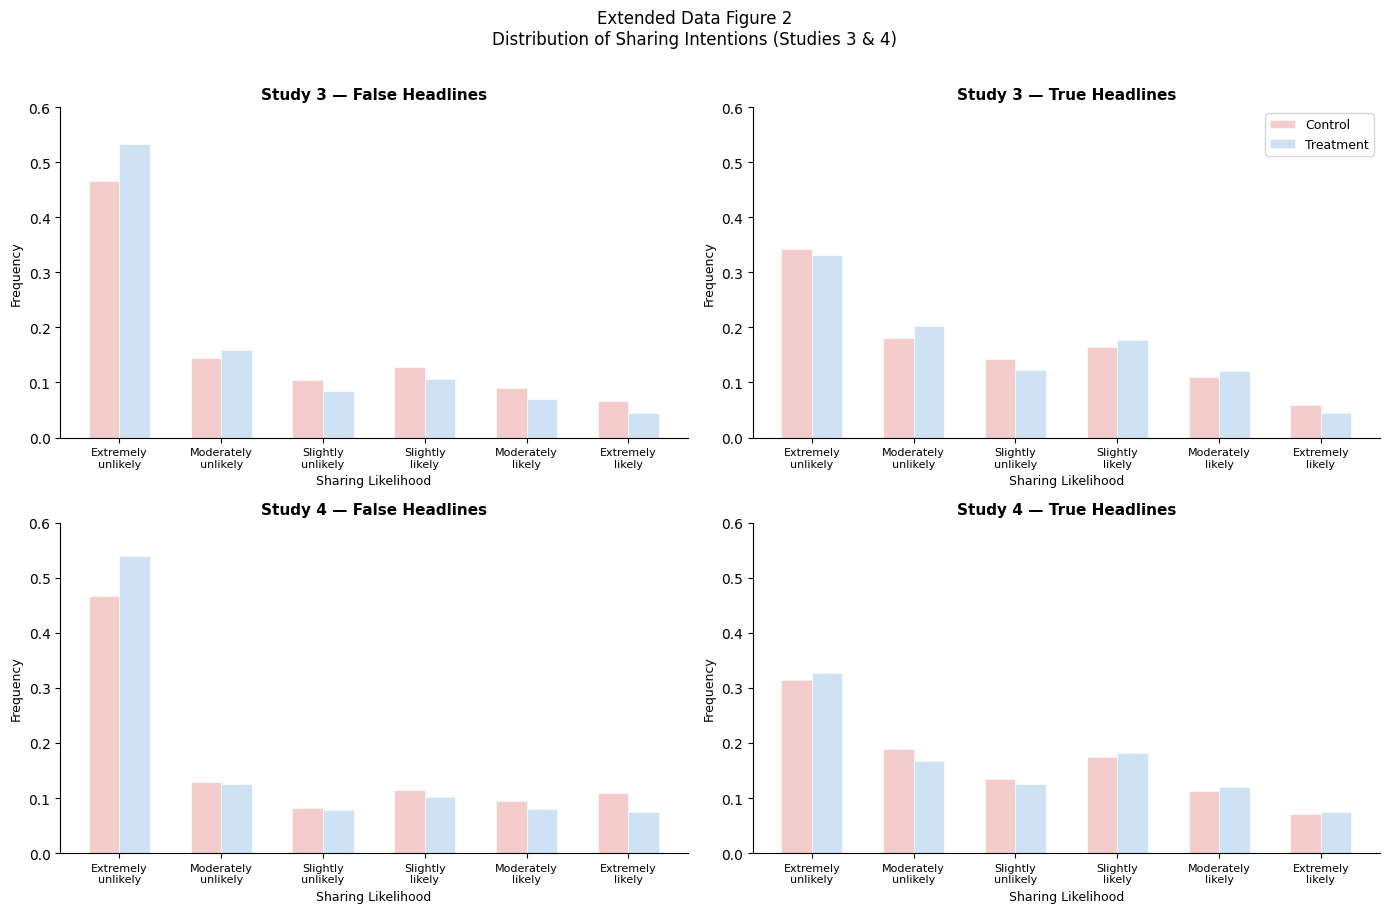

Saved: ExtDataFig2_Studies34.png


In [ ]:
# Extended Data Figure 2
SM_VALS   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
SM_LABELS = ['Extremely\nunlikely', 'Moderately\nunlikely', 'Slightly\nunlikely',
             'Slightly\nlikely',   'Moderately\nlikely',   'Extremely\nlikely']

sharers_long_copy = sharers_long.copy()
sharers_long_copy['sm_round'] = sharers_long_copy['sm'].round(1)

# 2 studies × 2 veracity = 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panel_labels = {
    (3, 0): 'Study 3 — False Headlines',
    (3, 1): 'Study 3 — True Headlines',
    (4, 0): 'Study 4 — False Headlines',
    (4, 1): 'Study 4 — True Headlines',
}
for row_i, study_id in enumerate([3, 4]):
    for col_i, real_val in enumerate([0, 1]):
        ax = axes[row_i][col_i]
        subset = sharers_long_copy[
            (sharers_long_copy['study'] == study_id) &
            (sharers_long_copy['real']  == real_val)]
        x = np.arange(len(SM_VALS))
        for i, cond in enumerate([0, 1]):
            grp   = subset[subset['condition'] == cond]
            total = len(grp)
            freqs = [(grp['sm_round'] == v).sum() / total if total > 0 else 0
                     for v in SM_VALS]
            offset = (i - 0.5) * 0.3
            ax.bar(x + offset, freqs, width=0.3,
                   color=COND_COLORS[cond], label=COND_LABELS[cond],
                   edgecolor='white', linewidth=0.4)
        ax.set_title(panel_labels[(study_id, real_val)],
                     fontsize=11, fontweight='bold', pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(SM_LABELS, fontsize=8)
        ax.set_xlabel('Sharing Likelihood', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.set_ylim(0, 0.6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=9, frameon=True, loc='upper right')

fig.suptitle('Extended Data Figure 2\nDistribution of Sharing Intentions (Studies 3 & 4)',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR + 'ExtDataFig2_Studies34.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ExtDataFig2_Studies34.png")

## 5. Accuracy Importance T-tests (+ Bayesian)

Does the accuracy nudge change how much participants say they care about accuracy?  If not, this rules out a simple "demand characteristics" explanation.

**Paper reports** (sharers only):
- AccImp: BF₁₀ = 0.063 (strong null evidence)
- AccImp_Friends: BF₁₀ = 0.095 (strong null evidence)

*The original Stata code only runs frequentist t-tests*  
We replicate them here using `pingouin` with the standard Cauchy prior (r = √2/2 ≈ 0.707).

In [32]:
# Wide-format df for participant-level variables
wide_sharers = df[df['socialmedia_chk'] == 1].copy()

# AccImp: no treatment effect on accuracy importance
# Stata: bysort study: ttest accimp if socialmedia_chk==1, by(condition)
#        ttest accimp if socialmedia_chk==1, by(condition) -> Pooled
print("=== AccImp: Treatment effect on perceived accuracy importance ===")
for s, label in [(3, 'Study 3'), (4, 'Study 4'), (None, 'Pooled S3+S4')]:
    sub = wide_sharers if s is None else wide_sharers[wide_sharers['study'] == s]
    g0 = sub[sub['condition'] == 0]['accimp']
    g1 = sub[sub['condition'] == 1]['accimp']
    ttest_report(f"{label} (frequentist)", g0, g1)
    bayesian_ttest_report(f"{label} (Bayesian)", g0, g1)

# AccImp_Friends: Study 4 only (variable not collected in Study 3)
# Stata: ttest accimp_friends if socialmedia_chk==1, by(condition)
# Note: runs without "bysort study", but Study 3 has no accimp_friends, so this is Study 4 only
print("\n=== AccImp_Friends: Treatment effect ===")
print("  (accimp_friends not collected in Study 3 — Study 4 only)")
sub4 = wide_sharers[wide_sharers['study'] == 4]
g0 = sub4[sub4['condition'] == 0]['accimp_friends']
g1 = sub4[sub4['condition'] == 1]['accimp_friends']
ttest_report("Study 4 (frequentist)", g0, g1)
bayesian_ttest_report("Study 4 (Bayesian)", g0, g1)

# AccImp vs AccImp_Friends: paired t-test
# Stata: ttest accimp==accimp_friends
#        -> interesting sidenote: people think they care more about accuracy than their friends do
# Note: Study 3 has no accimp_friends, so this is Study 4 only
print("\n=== AccImp vs AccImp_Friends: Paired t-test ===")
print("  (accimp_friends not collected in Study 3 — Study 4 only)")
both = wide_sharers[['accimp', 'accimp_friends']].dropna()
t_p, p_p = stats.ttest_rel(both['accimp'], both['accimp_friends'])
print(f"  AccImp mean={both['accimp'].mean():.4f}, "
      f"AccImp_Friends mean={both['accimp_friends'].mean():.4f}")
print(f"  t={t_p:.4f}, p={p_p:.4f}")

=== AccImp: Treatment effect on perceived accuracy importance ===
  Study 3 (frequentist): n0=359, mean0=4.2535 | n1=367, mean1=4.2888 | t=-0.4909, p=0.6237
  Study 3 (Bayesian): BF₁₀ = 0.0933
  Study 4 (frequentist): n0=393, mean0=4.3257 | n1=381, mean1=4.3333 | t=-0.1167, p=0.9071
  Study 4 (Bayesian): BF₁₀ = 0.0809
  Pooled S3+S4 (frequentist): n0=752, mean0=4.2912 | n1=748, mean1=4.3115 | t=-0.4180, p=0.6760
  Pooled S3+S4 (Bayesian): BF₁₀ = 0.0632

=== AccImp_Friends: Treatment effect ===
  (accimp_friends not collected in Study 3 — Study 4 only)
  Study 4 (frequentist): n0=388, mean0=3.2268 | n1=382, mean1=3.1806 | t=0.5711, p=0.5681
  Study 4 (Bayesian): BF₁₀ = 0.0945

=== AccImp vs AccImp_Friends: Paired t-test ===
  (accimp_friends not collected in Study 3 — Study 4 only)
  AccImp mean=4.3298, AccImp_Friends mean=3.2055
  t=25.2352, p=0.0000


## 6. Main Analysis — Table S2 (Two-Way Clustered OLS) + Table S3

All regressions using two-way clustered standard errors (by participant `id` and headline `item_num`).

### Supplementary information - Table S2

| Column | Sample | Study |
|--------|--------|-------|
| **(1)** | **Participants that share political content** | **Study 3** |
| **(2)** | **Participants that share political content** | **Study 4** |
| (3) | Participants that share political content | Study 3+4 *(see Section 8. Politics Moderation Analysis)* |
| **(4)** | **All participants** | **Study 3** |
| **(5)** | **All participants** | **Study 4** |
| (6) | All participants | Study 3+4 *(see Section 8. Politics Moderation Analysis)* |

**Key coefficients**:
- `condition` = effect of treatment on false headlines
- `real` = true/false gap in control group
- `condition:real` = **interaction** (does nudge widen discernment?)

**Paper reports** (sharers, interaction):
- Study 3: b=0.053, 95%CI[0.032, 0.074], F(1, 17413)=24.21, p<0.0001
- Study 4: b=0.065, 95%CI[0.036, 0.094], F(1, 18673)=19.53, p<0.0001

### Supplementary information - Table S3
**Simple effects p-values from each model correspond to Table S3 in the Supplementary Information.**

In [18]:
def print_simple_effects(model, smry, label=""):
    b = model.params
    se_d = smry['se']
    # Find interaction term (condition:real or condition*real)
    inter_key = [k for k in b.index if ':' in k or 'X' in k.upper()]
    cond_key = [k for k in b.index if k.lower() == 'condition']
    real_key = [k for k in b.index if k.lower() == 'real']
    if not inter_key or not cond_key or not real_key:
        return
    ik, ck, rk = inter_key[0], cond_key[0], real_key[0]

    def p_val(coef, se):
        t = coef / se
        return 2 * stats.t.sf(abs(t), df=model.df_resid)
    se = smry['se']
    # simple effect coefficients and their SEs
    b_real = b[rk]
    b_cond = b[ck]
    b_inter = b[ik]
    se_real = se[rk]
    se_cond = se[ck]
    # SE for linear combinations via delta method
    vcov = smry['se']
    cov_mat = model.cov_params()
    def combo_se(keys, signs):
        """SE of a linear combination via full covariance matrix."""
        c = sum(s * cov_mat.loc[k, k2] * s2
                for i, (k, s) in enumerate(zip(keys, signs))
                for j, (k2, s2) in enumerate(zip(keys, signs)))
        return np.sqrt(max(c, 0))
    se_real_in_treat = combo_se([rk, ik], [1, 1])
    se_cond_on_true = combo_se([ck, ik], [1, 1])

    p_real_ctrl = p_val(b_real, se_real)
    p_real_treat = p_val(b_real + b_inter, se_real_in_treat)
    p_cond_false = p_val(b_cond, se_cond)
    p_cond_true = p_val(b_cond + b_inter, se_cond_on_true)

    print(f"\n  Simple Effects ({label}):")
    print(f"    True/false gap in Control:            {b_real:+.4f}  (p={p_real_ctrl:.4f})")
    print(f"    True/false gap in Treatment:          {b_real+b_inter:+.4f}  (p={p_real_treat:.4f})")
    print(f"    Treatment effect on False headlines:  {b_cond:+.4f}  (p={p_cond_false:.4f})")
    print(f"    Treatment effect on True headlines:   {b_cond+b_inter:+.4f}  (p={p_cond_true:.4f})")
    print(f"    Interaction (b):                      {b_inter:+.4f}  (p={smry.loc[ik,'p']:.4f})")

formula = "sm ~ condition * real"

print("\n" + "="*70)
print("TABLE S2: Main regression (condition x real, sharers)")
print("="*70)

# Col 1: Study 3 sharers
s3_sh = sharers_long[sharers_long['study'] == 3].dropna(subset=['sm'])
m3, s3 = two_way_cluster_ols(formula, s3_sh, 'id', 'item_num',
                              "S2 Col 1: Study 3 — Sharers Only")
print_simple_effects(m3, s3, "Study 3 sharers")

# Col 2: Study 4 sharers
s4_sh = sharers_long[sharers_long['study'] == 4].dropna(subset=['sm'])
m4, s4 = two_way_cluster_ols(formula, s4_sh, 'id', 'item_num',
                              "S2 Col 2: Study 4 — Sharers Only")
print_simple_effects(m4, s4, "Study 4 sharers")

# Col 3: Study S3+S4 sharers
pool_sh = sharers_long.dropna(subset=['sm'])
mp, sp = two_way_cluster_ols(formula, pool_sh, 'id', 'item_num',
                              "S2 Col 3: Study 3+4 — Sharers Only")
print_simple_effects(mp, sp, "Study 3+4 sharers")


TABLE S2: Main regression (condition x real, sharers)

REGRESSION: S2 Col 1: Study 3 — Sharers Only
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.2853 0.0152  0.2555  0.3151 18.7472 0.0000
condition      -0.0545 0.0145 -0.0830 -0.0260 -3.7517 0.0002
real            0.0540 0.0205  0.0139  0.0941  2.6389 0.0083
condition:real  0.0529 0.0108  0.0319  0.0740  4.9199 0.0000
  N=17417, R²=0.0192

  Simple Effects (Study 3 sharers):
    True/false gap in Control:            +0.0540  (p=0.0083)
    True/false gap in Treatment:          +0.1069  (p=0.0000)
    Treatment effect on False headlines:  -0.0545  (p=0.0002)
    Treatment effect on True headlines:   -0.0016  (p=0.8197)
    Interaction (b):                      +0.0529  (p=0.0000)

REGRESSION: S2 Col 2: Study 4 — Sharers Only
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.3137 0.0221  0.2704  0.3571 14.1922 0.0000
condition      -0.0582 0.0168 -0.0911 -0.0253 -3.4625 0.00

In [19]:
print("\n" + "="*70)
print("TABLE S2: Main regression (condition x real, all participants)")
print("="*70)

# Col 4: Study 3 all
s3_all = long[long['study'] == 3].dropna(subset=['sm'])
m3a, s3a = two_way_cluster_ols(formula, s3_all, 'id', 'item_num',
                                "S2 Col 4: Study 3 — All Participants")
print_simple_effects(m3a, s3a, "Study 3 all")

# Col 5: Study 4 all
s4_all = long[long['study'] == 4].dropna(subset=['sm'])
m4a, s4a = two_way_cluster_ols(formula, s4_all, 'id', 'item_num',
                                "S2 Col 5: Study 4 — All Participants")
print_simple_effects(m4a, s4a, "Study 4 all")

# Col 6: Study 3+4 S3+S4 all
pool_all = long.dropna(subset=['sm'])
mpa, spa = two_way_cluster_ols(formula, pool_all, 'id', 'item_num',
                                "S2 Col 6: Study 3+4 — All Participants")
print_simple_effects(mpa, spa, "Study 3+4 all")


TABLE S2: Main regression (condition x real, all participants)

REGRESSION: S2 Col 4: Study 3 — All Participants
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.2343 0.0128  0.2092  0.2594 18.2761 0.0000
condition      -0.0294 0.0117 -0.0524 -0.0065 -2.5197 0.0117
real            0.0383 0.0169  0.0051  0.0715  2.2616 0.0237
condition:real  0.0475 0.0082  0.0314  0.0635  5.8003 0.0000
  N=27732, R²=0.0118

  Simple Effects (Study 3 all):
    True/false gap in Control:            +0.0383  (p=0.0237)
    True/false gap in Treatment:          +0.0858  (p=0.0000)
    Treatment effect on False headlines:  -0.0294  (p=0.0117)
    Treatment effect on True headlines:   +0.0180  (p=0.0005)
    Interaction (b):                      +0.0475  (p=0.0000)

REGRESSION: S2 Col 5: Study 4 — All Participants
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.2632 0.0182  0.2275  0.2990 14.4333 0.0000
condition      -0.0457 0.0139 -0.0729 -0.0186

## 7. Table S3 — Simple Effects by Partisanship × Concordance

### Supplementary information - Table S3

The p-values in Table S3 of the Supplementary Information come from the
Section 6 regressions above. However, the caption notes:

> *"p < .05 for all combinations except Republicans sharing concordant
> headlines when including all participants (p = .36)"*

This implies systematic tests across all 4 partisanship × concordance
combinations — but these are **absent from the author's Stata code**.
We implement them here as an addition.

For each subgroup, we run `sm ~ condition * real` with two-way clustered SEs
and report the `condition` p-value.

| Subgroup | Headline | Expected |
|----------|---------------|----------|
| Democrats | Concordant (pro-Democrat) | p < .05 |
| Democrats | Discordant (pro-Republican) | p < .05 |
| Republicans | Concordant (pro-Republican) | p = .36 |
| Republicans | Discordant (pro-Democrat) | p < .05 |

In [ ]:
# Table S3 caption: "p<.05 for all except Republicans concordant all participants (p=.36)"
# Tests "Treatment on false headlines" = the 'condition' coefficient
# from sm ~ condition * real, run separately for each partisanship × concordance subgroup.
# NOT in author's Stata code. Implemented here as an addition.

formula_s3 = "sm ~ condition * real"

for dr_val, dr_label in [(1, "Democrats"), (2, "Republicans")]:
    for conc_val, conc_label in [(1, "Concordant"), (0, "Discordant")]:
        sub = long[(long['demrep'] == dr_val) &
                   (long['politically_concordant'] == conc_val)
                   ].dropna(subset=['sm', 'condition', 'real']).copy()

        if len(sub) < 30:
            continue

        model, smry = two_way_cluster_ols(
            formula_s3, sub, 'id', 'item_num',
            label=f"{dr_label} | {conc_label}")
        b = model.params['condition']
        p = smry.loc['condition', 'p']
        print(f"{'Subgroup':<14} {'Headlines':<13} {'b':>8} {'p':>8}")
        print(f"{dr_label:<14} {conc_label:<13} {b:>+8.4f} {p:>8.4f}")


REGRESSION: Democrats | Concordant
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.2991 0.0186  0.2625  0.3356 16.0374 0.0000
condition      -0.0589 0.0137 -0.0857 -0.0322 -4.3159 0.0000
real            0.0288 0.0265 -0.0231  0.0807  1.0879 0.2767
condition:real  0.0894 0.0123  0.0653  0.1136  7.2503 0.0000
  N=19067, R²=0.0170
Subgroup       Headlines            b        p
Democrats      Concordant     -0.0589   0.0000

REGRESSION: Democrats | Discordant
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.1866 0.0129  0.1614  0.2118 14.5201 0.0000
condition      -0.0310 0.0104 -0.0515 -0.0106 -2.9769 0.0029
real            0.0443 0.0178  0.0094  0.0792  2.4854 0.0130
condition:real  0.0378 0.0061  0.0258  0.0497  6.1802 0.0000
  N=19057, R²=0.0141
Subgroup       Headlines            b        p
Democrats      Discordant     -0.0310   0.0029

REGRESSION: Republicans | Concordant
                  coef     se   CI_lo  CI_hi      

## 8. Table S2 (Col 3 & 6) — Politics Moderation Analysis

Does the treatment effect differ by **partisan concordance**?  
That is, does the accuracy nudge work differently for politically-congruent vs. incongruent headlines?

**Model**: Full 16-variable interaction model :  
`sm ~ condition + real + z_demrep + condition×real + z_demrep×real + condition×z_demrep + condition×z_demrep×real + z_concordant + z_concordant×real + z_concordant×condition + condition×real×z_concordant + z_concordant×z_demrep + z_concordant×condition×z_demrep + z_concordant×z_demrep×real + z_concordant×condition×z_demrep×real`

**Key test**: `conditionXrealXconcordant = 0`  
**Paper reports** (sharers, pooled): b=0.022, F(1, 36078)=18.09, p<0.0001  
**Interpretation**: The accuracy nudge increases discernment especially for politically-concordant headlines — ruling out a simple "backfire" effect among strong partisans.

In [21]:
def run_politics_moderation(data, label, demrep_filter=None):
    """
    Politics moderation regression (two-way clustered OLS).
    - demrep_filter=None : full model (16 vars, z_demrep included,
                           demrep missing → z_demrep=0, kept in sample)
    - demrep_filter=1 : Democrats only, simplified 8-var model
    - demrep_filter=2 : Republicans only, simplified 8-var model
    """
    sub = data.copy()
    sub = sub[sub['politically_concordant'].notna() & sub['sm'].notna()].copy()

    if demrep_filter is not None:
        # Democrats / Republicans: drop rows without party ID
        sub = sub[sub['demrep'] == demrep_filter].copy()
    else:
        # Full model: keep everyone, fill missing demrep with z=0
        sub = sub[sub['demrep'].notna() | sub['demrep'].isna()].copy()

    # z-score concordance
    sub['z_conc'] = zscore(sub['politically_concordant'], ddof=1, nan_policy='omit')

    # interaction terms shared by all models
    sub['condXreal'] = sub['condition'] * sub['real']
    sub['realXconc'] = sub['real'] * sub['z_conc']
    sub['condXconc'] = sub['condition'] * sub['z_conc']
    sub['condXrealXconc'] = sub['condition'] * sub['real'] * sub['z_conc']

    if demrep_filter is None:
        # Full 16-var model: add z_demrep and its interactions
        sub['z_demrep'] = zscore(sub['demrep'], ddof=1, nan_policy='omit')
        sub['z_demrep'] = sub['z_demrep'].fillna(0)  # missing demrep → 0

        sub['condXdr'] = sub['condition'] * sub['z_demrep']
        sub['drXreal'] = sub['z_demrep'] * sub['real']
        sub['condXdrXreal'] = sub['condition'] * sub['z_demrep'] * sub['real']
        sub['concXdr'] = sub['z_conc'] * sub['z_demrep']
        sub['concXcondXdr'] = sub['z_conc'] * sub['condition'] * sub['z_demrep']
        sub['concXdrXreal'] = sub['z_conc'] * sub['z_demrep'] * sub['real']
        sub['concXcondXdrXreal'] = sub['z_conc'] * sub['condition'] * sub['z_demrep'] * sub['real']

        formula = ("sm ~ condition + real + z_demrep"
                   " + condXreal + drXreal + condXdr + condXdrXreal"
                   " + z_conc + realXconc + condXconc + condXrealXconc"
                   " + concXdr + concXcondXdr + concXdrXreal + concXcondXdrXreal")
        key = 'condXrealXconc'
    else:
        # Simplified 8-var model (no z_demrep terms)
        formula = ("sm ~ condition + real + condXreal"
                   " + z_conc + realXconc + condXconc + condXrealXconc")
        key = 'condXreal'

    model, smry = two_way_cluster_ols(formula, sub, 'id', 'item_num', label)

    b  = model.params[key]
    se = smry.loc[key, 'se']
    t  = b / se
    p  = 2 * stats.t.sf(abs(t), df=model.df_resid)
    F  = t**2
    print(f"\n  Key test ({key}): b={b:+.4f}, SE={se:.4f}, "
          f"F(1,{int(model.df_resid)})={F:.2f}, p={p:.4f}")
    return model, smry

In [22]:
# Table S2 Col 3: Pooled (Studies 3+4) — Sharers only
run_politics_moderation(sharers_long,
    "Politics Moderation — Full Model (Pooled Sharers) - Table S2 Col 3")


REGRESSION: Politics Moderation — Full Model (Pooled Sharers) - Table S2 Col 3
                     coef     se   CI_lo   CI_hi       t      p
Intercept          0.2998 0.0125  0.2753  0.3243 23.9796 0.0000
condition         -0.0557 0.0110 -0.0772 -0.0343 -5.0844 0.0000
real               0.0494 0.0161  0.0179  0.0810  3.0730 0.0021
z_demrep           0.0169 0.0094 -0.0015  0.0353  1.7979 0.0722
condXreal          0.0589 0.0086  0.0421  0.0757  6.8671 0.0000
drXreal            0.0032 0.0093 -0.0150  0.0214  0.3463 0.7291
condXdr            0.0051 0.0106 -0.0157  0.0258  0.4797 0.6314
condXdrXreal      -0.0159 0.0086 -0.0328  0.0011 -1.8368 0.0662
z_conc             0.0684 0.0072  0.0542  0.0825  9.4494 0.0000
realXconc          0.0035 0.0107 -0.0174  0.0245  0.3283 0.7427
condXconc         -0.0156 0.0046 -0.0246 -0.0065 -3.3673 0.0008
condXrealXconc     0.0224 0.0053  0.0121  0.0328  4.2525 0.0000
concXdr           -0.0035 0.0093 -0.0217  0.0147 -0.3796 0.7042
concXcondXdr       0.007

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x127226b40>,
                        coef        se     CI_lo     CI_hi          t  \
 Intercept          0.299766  0.012501  0.275265  0.324268  23.979624   
 condition         -0.055742  0.010963 -0.077230 -0.034254  -5.084430   
 real               0.049434  0.016087  0.017904  0.080964   3.072996   
 z_demrep           0.016891  0.009395 -0.001523  0.035305   1.797865   
 condXreal          0.058863  0.008572  0.042062  0.075663   6.867099   
 drXreal            0.003220  0.009299 -0.015006  0.021447   0.346317   
 condXdr            0.005078  0.010586 -0.015671  0.025828   0.479711   
 condXdrXreal      -0.015865  0.008637 -0.032794  0.001064  -1.836809   
 z_conc             0.068352  0.007233  0.054174  0.082530   9.449365   
 realXconc          0.003511  0.010694 -0.017449  0.024470   0.328295   
 condXconc         -0.015569  0.004624 -0.024631 -0.006507  -3.367303   
 condXrealXconc     0.022424  0.005273  0.01

In [23]:
# Table S2 Col 6: Pooled (Studies 3+4) — All participants
run_politics_moderation(long,
    "Politics Moderation — Full Model (All Participants) - Table S2 Col 6")


REGRESSION: Politics Moderation — Full Model (All Participants) - Table S2 Col 6
                     coef     se   CI_lo   CI_hi       t      p
Intercept          0.2490 0.0106  0.2284  0.2697 23.6032 0.0000
condition         -0.0372 0.0090 -0.0548 -0.0195 -4.1202 0.0000
real               0.0380 0.0138  0.0109  0.0650  2.7534 0.0059
z_demrep           0.0090 0.0080 -0.0067  0.0248  1.1219 0.2619
condXreal          0.0557 0.0068  0.0423  0.0690  8.1737 0.0000
drXreal            0.0025 0.0079 -0.0130  0.0180  0.3150 0.7528
condXdr            0.0111 0.0081 -0.0048  0.0270  1.3726 0.1699
condXdrXreal      -0.0113 0.0057 -0.0225 -0.0000 -1.9647 0.0495
z_conc             0.0524 0.0062  0.0401  0.0646  8.3846 0.0000
realXconc          0.0040 0.0090 -0.0136  0.0215  0.4418 0.6587
condXconc         -0.0072 0.0032 -0.0134 -0.0010 -2.2923 0.0219
condXrealXconc     0.0163 0.0029  0.0106  0.0220  5.6215 0.0000
concXdr           -0.0055 0.0083 -0.0218  0.0109 -0.6566 0.5115
concXcondXdr       0.0

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x127078170>,
                        coef        se     CI_lo     CI_hi          t  \
 Intercept          0.249043  0.010551  0.228363  0.269723  23.603240   
 condition         -0.037153  0.009017 -0.054827 -0.019479  -4.120219   
 real               0.037956  0.013785  0.010938  0.064975   2.753443   
 z_demrep           0.009019  0.008039 -0.006737  0.024776   1.121948   
 condXreal          0.055672  0.006811  0.042322  0.069022   8.173666   
 drXreal            0.002494  0.007918 -0.013024  0.018012   0.315012   
 condXdr            0.011107  0.008092 -0.004753  0.026967   1.372579   
 condXdrXreal      -0.011260  0.005731 -0.022493 -0.000027  -1.964676   
 z_conc             0.052396  0.006249  0.040148  0.064644   8.384620   
 realXconc          0.003962  0.008968 -0.013615  0.021538   0.441754   
 condXconc         -0.007228  0.003153 -0.013407 -0.001048  -2.292329   
 condXrealXconc     0.016310  0.002901  0.01

In [26]:
# Democrats only — simplified model
run_politics_moderation(sharers_long,
    "Politics Moderation — Democrats (Pooled Sharers)",
    demrep_filter=1)

# Republicans only — simplified model
run_politics_moderation(sharers_long,
    "Politics Moderation — Republicans (Pooled Sharers)",
    demrep_filter=2)


REGRESSION: Politics Moderation — Democrats (Pooled Sharers)
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.2880 0.0147  0.2592  0.3168 19.6253 0.0000
condition      -0.0592 0.0135 -0.0856 -0.0328 -4.3996 0.0000
real            0.0478 0.0189  0.0108  0.0848  2.5313 0.0114
condXreal       0.0692 0.0109  0.0479  0.0906  6.3550 0.0000
z_conc          0.0711 0.0115  0.0485  0.0937  6.1727 0.0000
realXconc      -0.0077 0.0179 -0.0428  0.0274 -0.4317 0.6660
condXconc      -0.0205 0.0059 -0.0321 -0.0090 -3.4888 0.0005
condXrealXconc  0.0321 0.0061  0.0202  0.0440  5.2941 0.0000
  N=24644, R²=0.0593

  Key test (condXreal): b=+0.0692, SE=0.0109, F(1,24636)=40.39, p=0.0000

REGRESSION: Politics Moderation — Republicans (Pooled Sharers)
                  coef     se   CI_lo   CI_hi       t      p
Intercept       0.3244 0.0175  0.2901  0.3587 18.5454 0.0000
condition      -0.0483 0.0185 -0.0846 -0.0120 -2.6106 0.0090
real            0.0547 0.0179  0.0196  0.0898  

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x127317ce0>,
                     coef        se     CI_lo     CI_hi          t  \
 Intercept       0.324369  0.017491  0.290087  0.358650  18.545355   
 condition      -0.048299  0.018501 -0.084561 -0.012038  -2.610649   
 real            0.054725  0.017919  0.019603  0.089846   3.053995   
 condXreal       0.035128  0.014435  0.006836  0.063420   2.433618   
 z_conc          0.063516  0.012396  0.039220  0.087812   5.123966   
 realXconc       0.026148  0.015743 -0.004709  0.057005   1.660906   
 condXconc      -0.004896  0.008007 -0.020590  0.010799  -0.611409   
 condXrealXconc  0.002873  0.008634 -0.014048  0.019795   0.332800   
 
                            p  
 Intercept       1.149202e-75  
 condition       9.048882e-03  
 real            2.263374e-03  
 condXreal       1.496402e-02  
 z_conc          3.040719e-07  
 realXconc       9.675982e-02  
 condXconc       5.409410e-01  
 condXrealXconc  7.392915e-01  )

## 9. Mechanism Analysis — Figure 3a (Study 3) & Figure 3b (Study 4)

**Logic in Paper**: If inattention (not ignorance or motivated reasoning) drives misinformation sharing, then priming accuracy should have the largest effect on headlines that participants could already identify as false if they stopped to think.  
-> The treatment effect per headline should *correlate positively* with that headline's pre-rated *perceived accuracy*  
-> perceived accuracy ↑ → treatment effect ↑ (positive correlation)

**Paper reports**:
- Study 3: r(22) = 0.71, p = 0.0001
- Study 4: r(22) = 0.67, p = 0.0003

**Steps**:
1. Collapse to item level → compute treatment effects
2. Merge pre-test `likelihood` ratings
3. Pearson correlation → Figures 3a & 3b

In [24]:
# Pre-test likelihood ratings are from Stata .do file
likelihood_s3 = {
    # true headlines (13-24 in Stata = items 13-24)
    13: 4.979166667, 14: 3.96875,    15: 4.135416667, 16: 4.572916667,
    17: 4.489583333, 18: 4.5625,     19: 4.614583333, 20: 4.114583333,
    21: 4.53125,     22: 4.708333333, 23: 4.197916667, 24: 5.0,
    # fake headlines (1-12 in Stata)
    1:  2.777777778, 2:  1.939393939, 3:  3.373737374, 4:  3.363636364,
    5:  1.909090909, 6:  2.402061856, 7:  3.282828283, 8:  3.242424242,
    9:  2.01010101,  10: 2.357142857, 11: 2.333333333, 12: 3.581632653,}
likelihood_s4 = {
    1:  1.61,  2:  3.06,  3:  2.25,  4:  3.68,  5:  2.7,   6:  3.65,
    7:  3.29,  8:  2.72,  9:  2.68,  10: 4.37,  11: 2.67,  12: 2.28,
    13: 4.41,  14: 4.46,  15: 4.29,  16: 5.07,  17: 5.07,  18: 5.18,
    19: 5.18,  20: 5.24,  21: 5.16,  22: 3.63,  23: 4.98,  24: 4.66,}

def get_likelihood(row):
    n = row['item_n_raw']
    real = row['real']
    study = int(row['study'])
    key = n if real == 0 else n + 12   # bc true items are 13-24
    if study == 3:
        return likelihood_s3.get(key, np.nan)
    else:
        return likelihood_s4.get(key, np.nan)

sharers_long = sharers_long.copy()
sharers_long['likelihood'] = sharers_long.apply(get_likelihood, axis=1)
print(sharers_long.groupby(['study','real'])['likelihood'].describe().round(3))

             count   mean    std    min    25%    50%    75%    max
study real                                                         
3     0     8724.0  2.714  0.601  1.909  2.253  2.590  3.303  3.582
      1     8724.0  4.490  0.316  3.969  4.182  4.547  4.638  5.000
4     0     9360.0  2.913  0.716  1.610  2.572  2.710  3.380  4.370
      1     9360.0  4.778  0.474  3.630  4.448  5.025  5.165  5.240


  Study 3: r = 0.7107, p = 0.0001
  Study 4: r = 0.6739, p = 0.0003


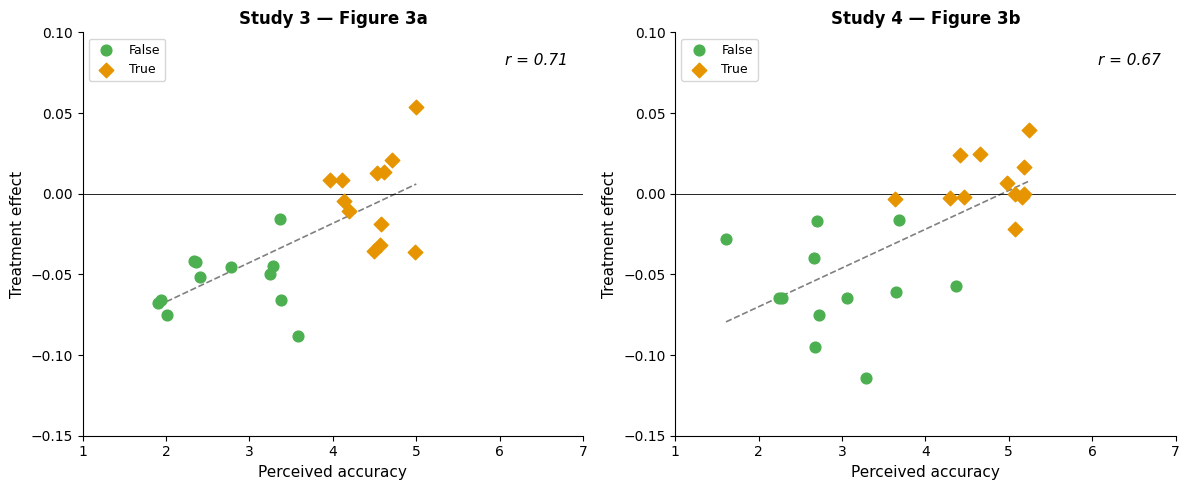

Saved: Figure_3ab_Studies34.png


In [28]:
# Figure 3a, 3b
ig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, study_id, fig_label in zip(axes, [3, 4], ['Study 3 — Figure 3a', 'Study 4 — Figure 3b']):
    sub_study = sharers_long[sharers_long['study'] == study_id].copy()

    item_means = (sub_study
                  .groupby(['item_n_raw', 'real', 'condition'])
                  .agg(sm_mean=('sm', 'mean'), likelihood=('likelihood', 'first'))
                  .reset_index())

    item_wide = item_means.pivot_table(
        index=['item_n_raw', 'real', 'likelihood'],
        columns='condition', values='sm_mean').reset_index()
    item_wide.columns.name = None
    item_wide.rename(columns={0: 'sm_ctrl', 1: 'sm_treat'}, inplace=True)
    item_wide = item_wide.dropna(subset=['sm_ctrl', 'sm_treat', 'likelihood'])
    item_wide['treatment_effect'] = item_wide['sm_treat'] - item_wide['sm_ctrl']

    r, p = stats.pearsonr(item_wide['likelihood'], item_wide['treatment_effect'])
    print(f"  Study {study_id}: r = {r:.4f}, p = {p:.4f}")

    is_true = item_wide['real'] == 1
    ax.scatter(item_wide.loc[~is_true, 'likelihood'],
               item_wide.loc[~is_true, 'treatment_effect'],
               color='#4CAF50', marker='o', s=60, zorder=3, label='False')
    ax.scatter(item_wide.loc[is_true,  'likelihood'],
               item_wide.loc[is_true,  'treatment_effect'],
               color='#E69500', marker='D', s=55, zorder=3, label='True')

    m_fit, b_fit = np.polyfit(item_wide['likelihood'], item_wide['treatment_effect'], 1)
    xr = np.linspace(item_wide['likelihood'].min(), item_wide['likelihood'].max(), 100)
    ax.plot(xr, m_fit*xr + b_fit, color='gray', linewidth=1.2, linestyle='--', zorder=2)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.text(0.97, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11, style='italic')
    ax.set_xlabel('Perceived accuracy', fontsize=11)
    ax.set_ylabel('Treatment effect', fontsize=11)
    ax.set_title(fig_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, frameon=True, loc='upper left')
    ax.set_xlim(1, 7)
    ax.set_ylim(-0.15, 0.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR + 'Figure_3ab_Studies34.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Figure_3ab_Studies34.png")

## 10. CRT Analysis (additional analysis - PAP O, Paper X, Stata X)

Included in the PAP for Studies 3 & 4, but not implemented in the published paper or the provided Stata code. Thus, we conduct this as an additional analysis.

**Cognitive Reflection Test (CRT)** measures intuitive vs. analytical thinking  (CRT ↑ = analytical thinking ↑)

*Can Find exact questions in "Study 3 materials (qualtrics).qsf" file*.  

Rand version  (CRT1_1~3)
- CRT1_1  Mark & Adam ages   → correct = 4
- CRT1_2  10 printers        → correct = 10
- CRT1_3  Mold doubling      → correct = 39  

Thompson version (CRT3_1~4)
- CRT3_1  Race passing       → correct = 2 *(EXCLUDED: under 25% response rate)*
- CRT3_2  Farmer's sheep     → correct = 8
- CRT3_3  Emily's father     → correct = "emily"
- CRT3_4  Dirt in hole       → correct = 0  

Total CRT (0-6) = Rand (0-3) + Thompson excl. CRT3_1 (0-3)


**Hypothesis**: Higher CRT → greater discernment, potentially stronger treatment effect

**Test**: Three-way interaction `condition × real × CRT_score`  
If significant → analytic thinkers show a *larger* accuracy nudge effect

In [ ]:
# Data Preprocessing

# Score CRT3_3 from restored text column
df['crt3_3_c'] = (
    df['crt3_3_text'].astype(str).str.strip().str.lower() == 'emily'
).astype(float)
df.loc[df['crt3_3_text'].isna(), 'crt3_3_c'] = np.nan

# Score CRT (numeric)
RAND_CORRECT = {'crt1_1': 4, 'crt1_2': 10, 'crt1_3': 39}
THOMPSON_CORRECT = {'crt3_2': 8, 'crt3_4': 0}

sharers_long_crt = sharers_long.copy()
for col, correct in RAND_CORRECT.items():
    sharers_long_crt[f'{col}_c'] = (
        pd.to_numeric(sharers_long_crt[col], errors='coerce') == correct
    ).astype(float)
    sharers_long_crt.loc[sharers_long_crt[col].isna(), f'{col}_c'] = np.nan
rand_c_cols = ['crt1_1_c', 'crt1_2_c', 'crt1_3_c']
sharers_long_crt['crt_rand'] = (sharers_long_crt[rand_c_cols].sum(axis=1, min_count=1))

wide_thompson = df.copy()
wide_thompson['id'] = wide_thompson['id'].astype(float)
for col, correct in THOMPSON_CORRECT.items():
    if col in wide_thompson.columns:
        wide_thompson[f'{col}_c'] = (
            pd.to_numeric(wide_thompson[col], errors='coerce') == correct).astype(float)
        wide_thompson.loc[wide_thompson[col].isna(), f'{col}_c'] = np.nan
    else:
        print(f"  Warning: {col} not found in df")
thompson_num_cols = [f'{c}_c' for c in THOMPSON_CORRECT if f'{c}_c' in wide_thompson.columns]

# Merge all CRT scores
thompson_merge = (wide_thompson[['id'] + thompson_num_cols + ['crt3_3_c']].drop_duplicates(subset='id'))
sharers_long_crt = sharers_long_crt.merge(thompson_merge, on='id', how='left')
all_thompson_c = thompson_num_cols + ['crt3_3_c']
sharers_long_crt['crt_thompson'] = (sharers_long_crt[all_thompson_c].sum(axis=1, min_count=1))
sharers_long_crt['crt_total'] = (sharers_long_crt['crt_rand'] + sharers_long_crt['crt_thompson'])


In [30]:
# Descriptive statistics (sharers only)
sharers_crt_wide = (sharers_long_crt[sharers_long_crt['socialmedia_chk'] == 1]
                    [['id', 'study', 'crt_rand', 'crt_thompson', 'crt_total']].drop_duplicates(subset='id'))

for s in [3, 4]:
    sub = sharers_crt_wide[sharers_crt_wide['study'] == s]
    print(f"\n  Study {s}  (n = {len(sub)})")
    for col, label in [('crt_rand', 'Rand (0-3)'),
                        ('crt_thompson', 'Thompson (0-3)'),
                        ('crt_total', 'Total (0-6)')]:
        sc = sub[col]
        print(f"    {label}: mean={sc.mean():.3f}, sd={sc.std():.3f}, "
              f"n_valid={sc.notna().sum()}")
    print(f"    Total distribution: "
          f"{sub['crt_total'].value_counts().sort_index().to_dict()}")


  Study 3  (n = 727)
    Rand (0-3): mean=1.036, sd=1.063, n_valid=727
    Thompson (0-3): mean=1.574, sd=0.843, n_valid=726
    Total (0-6): mean=2.610, sd=1.604, n_valid=726
    Total distribution: {0.0: 79, 1.0: 107, 2.0: 180, 3.0: 139, 4.0: 121, 5.0: 73, 6.0: 27}

  Study 4  (n = 780)
    Rand (0-3): mean=1.045, sd=1.091, n_valid=780
    Thompson (0-3): mean=1.581, sd=0.843, n_valid=780
    Total (0-6): mean=2.626, sd=1.639, n_valid=780
    Total distribution: {0.0: 82, 1.0: 129, 2.0: 186, 3.0: 137, 4.0: 124, 5.0: 92, 6.0: 30}


In [31]:
# 3-way interaction: condition × real × crt_z
crt_formula = "sm ~ condition * real * crt_z"
sharers_crt = sharers_long_crt[sharers_long_crt['socialmedia_chk'] == 1].copy()

results_crt = {}
for s, label in [(3, "Study 3 — Sharers"), (4, "Study 4 — Sharers"), (None, "Pooled Studies 3+4 — Sharers")]:

    sub = (sharers_crt if s is None
           else sharers_crt[sharers_crt['study'] == s]).copy()
    sub = sub.dropna(subset=['sm', 'condition', 'real', 'crt_total'])

    if len(sub) < 30:
        print(f"\n  [{label}]: insufficient data (n={len(sub)}), skipping.")
        continue

    # Z-score CRT within each subsample for interpretability
    sub['crt_z'] = zscore(sub['crt_total'], ddof=1, nan_policy='omit')

    model, smry = two_way_cluster_ols(crt_formula, sub, 'id', 'item_num', label)
    results_crt[label] = (model, smry)

    print(f"\n  [{label}]  n_obs={len(sub)}")
    for key in model.params.index:
        b      = model.params[key]
        se     = smry.loc[key, 'se']
        t      = b / se
        p      = 2 * stats.t.sf(abs(t), df=model.df_resid)
        sig    = ('***' if p < .001 else '**' if p < .01
                  else '*'   if p < .05 else '')
        print(f"    {key:<40s}  b={b:+.4f}  t={t:+.3f}  "
              f"p={p:.4f} {sig}")


REGRESSION: Study 3 — Sharers
                        coef     se   CI_lo   CI_hi       t      p
Intercept             0.2823 0.0149  0.2530  0.3115 18.9006 0.0000
condition            -0.0496 0.0140 -0.0769 -0.0222 -3.5520 0.0004
real                  0.0549 0.0205  0.0148  0.0951  2.6815 0.0073
condition:real        0.0515 0.0106  0.0308  0.0722  4.8743 0.0000
crt_z                -0.0560 0.0126 -0.0807 -0.0314 -4.4548 0.0000
condition:crt_z       0.0066 0.0144 -0.0216  0.0348  0.4595 0.6459
real:crt_z            0.0198 0.0116 -0.0029  0.0426  1.7065 0.0879
condition:real:crt_z -0.0064 0.0094 -0.0247  0.0120 -0.6780 0.4978
  N=17393, R²=0.0387

  [Study 3 — Sharers]  n_obs=17393
    Intercept                                 b=+0.2823  t=+18.901  p=0.0000 ***
    condition                                 b=-0.0496  t=-3.552  p=0.0004 ***
    real                                      b=+0.0549  t=+2.682  p=0.0073 **
    condition:real                            b=+0.0515  t=+4.874  p=

- The 3-way interaction (`condition × real × crt_z`) was not significant across all analyses (Study 3: p = 0.498; Study 4: p = 0.526; Pooled: p = 0.886), indicating that the accuracy nudge effect did not vary as a function of CRT performance.

- However, this result is meaningful. The fact that the treatment effect was equivalent regardless of CRT score suggests that misinformation sharing is not primarily a matter of analytic ability, but rather of attention — consistent with the main analysis results.

- Also, the `real × crt_z` interaction was positive and significant in Study 4 and the pooled analysis, indicating that higher CRT participants showed greater baseline discernment between true and false headlines. It means analytic thinking predicts greater accuracy in evaluating the veracity of news headlines.